# 03 · Evaluación del modelo
Entrada: `models/modelado.joblib` (pipelines + partición de la fase 3)
Salida: tabla de métricas (LaTeX), figura 5 (matriz de confusión + ROC).

Flujo: línea base → métricas en test → matriz de confusión → ROC/AUC →
validación cruzada → análisis del umbral de decisión.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

ROOT = Path("..")
FIGS = ROOT / "figures"

plt.rcParams.update({
    "font.family": "serif", "font.size": 9, "axes.labelsize": 9,
    "axes.titlesize": 10, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "savefig.bbox": "tight",
})
ANCHO = 6.3

arte = joblib.load(ROOT / "models/modelado.joblib")
pipe_logit, pipe_rf = arte["pipe_logit"], arte["pipe_rf"]
X_tr, X_te, y_tr, y_te = arte["X_tr"], arte["X_te"], arte["y_tr"], arte["y_te"]

METRICAS = list(X_tr.columns)

In [2]:
print(f"Línea base (predecir siempre 'no'): accuracy = {1 - y_te.mean():.2f}\n")

def evaluar(pipe, X, y):
    yp   = pipe.predict(X)
    ypro = pipe.predict_proba(X)[:, 1]
    return {
        "Exactitud (accuracy)":  accuracy_score(y, yp),
        "Precisión (precision)": precision_score(y, yp),
        "Sensibilidad (recall)": recall_score(y, yp),
        "F1-score":              f1_score(y, yp),
        "AUC-ROC":               roc_auc_score(y, ypro),
    }

res = pd.DataFrame({
    "Reg. logística": evaluar(pipe_logit, X_te, y_te),
    "Random Forest":  evaluar(pipe_rf,   X_te, y_te),
}).round(2)
res

Línea base (predecir siempre 'no'): accuracy = 0.67



,Reg. logística,Random Forest
Exactitud (accuracy),0.67,0.58
Precisión (precision),0.50,0.33
Sensibilidad (recall),0.25,0.25
F1-score,0.33,0.29
AUC-ROC,0.66,0.56


In [3]:
yp = pipe_logit.predict(X_te)
cm = confusion_matrix(y_te, yp)
tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos positivos (talentos detectados):      {tp}")
print(f"Falsos negativos (talentos que se ESCAPAN):      {fn}  <- error caro")
print(f"Falsos positivos (seguimiento 'malgastado'):     {fp}  <- error barato")
print(f"Verdaderos negativos:                            {tn}")

Verdaderos positivos (talentos detectados):      1
Falsos negativos (talentos que se ESCAPAN):      3  <- error caro
Falsos positivos (seguimiento 'malgastado'):     1  <- error barato
Verdaderos negativos:                            7


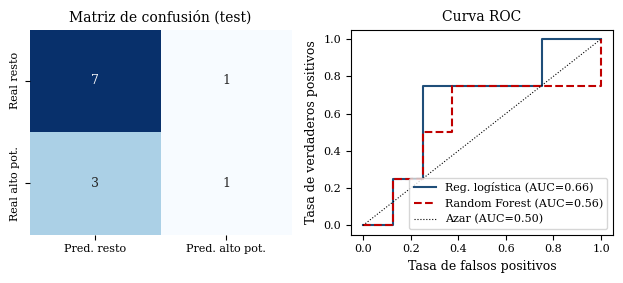

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(ANCHO, 2.9))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred. resto", "Pred. alto pot."],
            yticklabels=["Real resto", "Real alto pot."])
axes[0].set_title("Matriz de confusión (test)")

for nombre, pipe, color, ls in [("Reg. logística", pipe_logit, "#1f4e79", "-"),
                                 ("Random Forest",  pipe_rf,   "#c00000", "--")]:
    ypro = pipe.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, ypro)
    auc = roc_auc_score(y_te, ypro)
    axes[1].plot(fpr, tpr, color=color, ls=ls, label=f"{nombre} (AUC={auc:.2f})")

axes[1].plot([0, 1], [0, 1], "k:", lw=0.8, label="Azar (AUC=0.50)")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC")
axes[1].legend(loc="lower right")

fig.tight_layout()
fig.savefig(FIGS / "fig5_evaluacion.pdf")

In [5]:
X = pd.concat([X_tr, X_te])          # CV sobre el conjunto completo
y = pd.concat([y_tr, y_te])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

for nombre, pipe in [("Reg. logística", pipe_logit), ("Random Forest", pipe_rf)]:
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    print(f"{nombre:14s} · AUC por fold: {np.round(aucs, 2)}"
          f"  ->  {aucs.mean():.2f} ± {aucs.std():.2f}")

Reg. logística · AUC por fold: [0.5  0.87 0.8  0.53 0.4 ]  ->  0.62 ± 0.18
Random Forest  · AUC por fold: [0.33 0.8  0.87 0.8  0.4 ]  ->  0.64 ± 0.23


In [6]:
ypro = pipe_logit.predict_proba(X_te)[:, 1]

filas = []
for umbral in [0.30, 0.40, 0.50, 0.60]:
    yp_u = (ypro >= umbral).astype(int)
    filas.append({
        "Umbral": umbral,
        "Jugadores señalados": yp_u.sum(),
        "Recall": recall_score(y_te, yp_u),
        "Precision": precision_score(y_te, yp_u, zero_division=0),
    })
pd.DataFrame(filas).round(2)

,Umbral,Jugadores señalados,Recall,Precision
0,0.3,4,0.50,0.50
1,0.4,3,0.25,0.33
2,0.5,2,0.25,0.50
3,0.6,2,0.25,0.50


In [9]:
cv_row = {}
for nombre, pipe in [("Reg. logística", pipe_logit), ("Random Forest", pipe_rf)]:
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    cv_row[nombre] = f"{aucs.mean():.2f} $\\pm$ {aucs.std():.2f}"

res.loc["AUC-ROC (CV 5-fold)"] = pd.Series(cv_row)

res.style.to_latex(ROOT / "informe/tablas/tab_metricas.tex", hrules=True)
res

,Reg. logística,Random Forest
Exactitud (accuracy),0.67,0.58
Precisión (precision),0.5,0.33
Sensibilidad (recall),0.25,0.25
F1-score,0.33,0.29
AUC-ROC,0.66,0.56
AUC-ROC (CV 5-fold),0.62 $\pm$ 0.18,0.64 $\pm$ 0.23
